In [2]:
## imports
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from iqwav.io import load_raw_iq
from iqwav.dsp import magnitude_spectrum, welch_psd, spectrogram_data

In [3]:
## known metadata

path = Path("../../data/external/fm_rds_250k_1Msamples.iq")

fs = 250_000
center_freq = 99.5e6

print("Exists:", path.exists())
print("File size:", path.stat().st_size, "bytes")

Exists: True
File size: 8000000 bytes


In [7]:
## load

iq = load_raw_iq(path, dtype=np.float32, iq_order="IQ")

print("Samples:", len(iq))
print("Dtype:", iq.dtype)
print("Duration:", len(iq) / fs, "seconds")

print("\nFirst 5 samples:")
print(iq[:5])

Samples: 1000000
Dtype: complex128
Duration: 4.0 seconds

First 5 samples:
[ 2.26752535e-02-0.08462783j  2.73140669e-02-0.08285775j
  1.98370311e-02-0.08728294j  9.15555283e-05-0.08801538j
 -1.37638478e-02-0.08398694j]


In [8]:
direct = np.fromfile(path, dtype=np.complex64).astype(np.complex128)

print("Same sample count:", len(iq) == len(direct))
print("IQWAV matches direct complex64 read:", np.allclose(iq, direct))

Same sample count: True
IQWAV matches direct complex64 read: True


In [9]:
## inspect real samples

print("Mean I:", np.mean(iq.real))
print("Mean Q:", np.mean(iq.imag))

print("Mean complex value:", np.mean(iq))
print("Average power:", np.mean(np.abs(iq) ** 2))

print("Maximum magnitude:", np.max(np.abs(iq)))

Mean I: 0.00016390679536480458
Mean Q: -0.0003411137726670131
Mean complex value: (0.00016390679536480455-0.0003411137726670131j)
Average power: 0.010415098807110298
Maximum magnitude: 0.1272241842442671


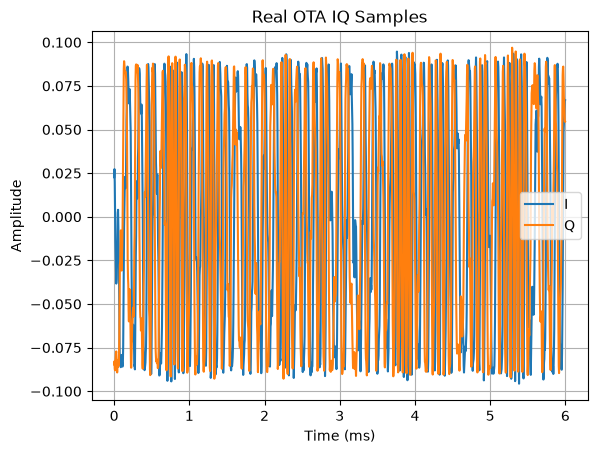

In [10]:
n = 1500
t = np.arange(n) / fs

plt.plot(t * 1000, iq[:n].real, label="I")
plt.plot(t * 1000, iq[:n].imag, label="Q")

plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.title("Real OTA IQ Samples")
plt.legend()
plt.grid()
plt.show()

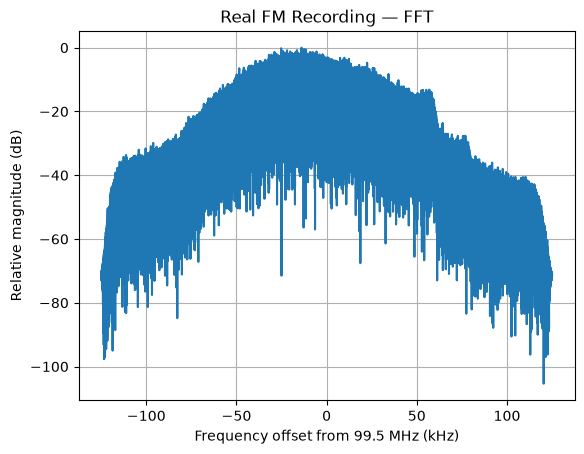

In [11]:
segment = iq[:262144]

freqs, mag = magnitude_spectrum(
    segment,
    fs
)

mag_db = 20 * np.log10(
    mag / np.max(mag) + 1e-12
)

plt.plot(freqs / 1000, mag_db)

plt.xlabel("Frequency offset from 99.5 MHz (kHz)")
plt.ylabel("Relative magnitude (dB)")
plt.title("Real FM Recording — FFT")
plt.grid()

plt.show()

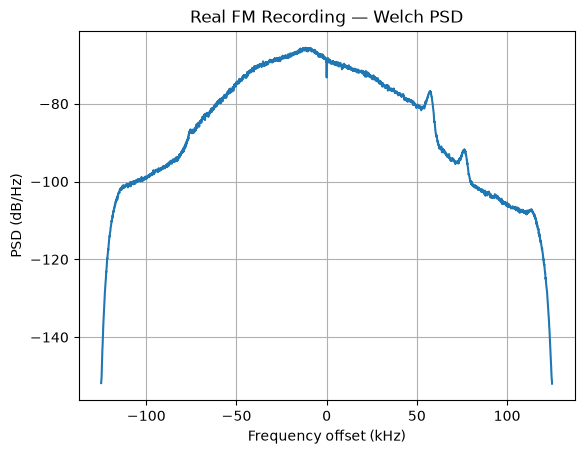

In [12]:
f_psd, psd = welch_psd(
    iq,
    fs,
    nperseg=4096
)

psd_db = 10 * np.log10(
    psd + 1e-20
)

plt.plot(f_psd / 1000, psd_db)

plt.xlabel("Frequency offset (kHz)")
plt.ylabel("PSD (dB/Hz)")
plt.title("Real FM Recording — Welch PSD")
plt.grid()

plt.show()

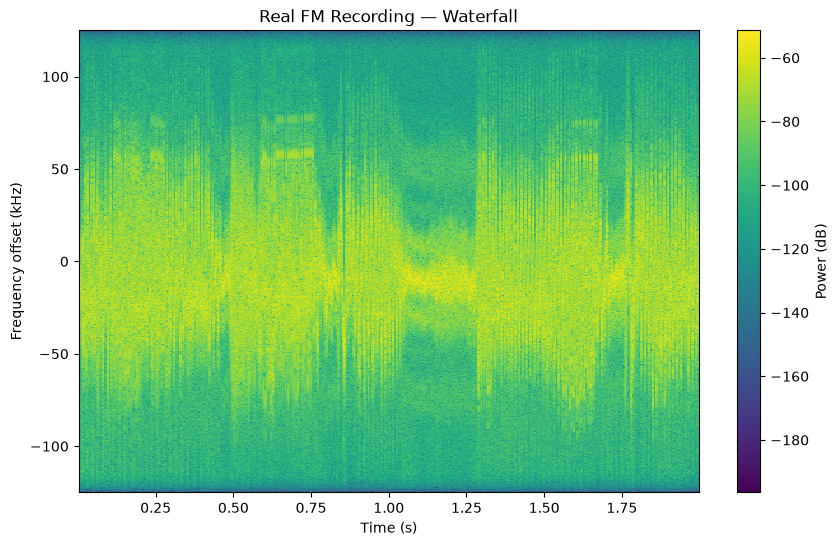

In [13]:
spec_samples = iq[:500000]

times, freqs_spec, power = spectrogram_data(
    spec_samples,
    fs,
    nperseg=2048,
    noverlap=1024
)

power_db = 10 * np.log10(
    power + 1e-20
)

plt.figure(figsize=(10, 6))

plt.pcolormesh(
    times,
    freqs_spec / 1000,
    power_db,
    shading="auto"
)

plt.xlabel("Time (s)")
plt.ylabel("Frequency offset (kHz)")
plt.title("Real FM Recording — Waterfall")
plt.colorbar(label="Power (dB)")

plt.show()